## 1. Persiapan Lingkungan dan Pemrosesan Data
Memuat pustaka inti seperti TensorFlow dan Pandas. Baris terakhir menjalankan pengecekan perangkat keras untuk memastikan sistem mendeteksi GPU. Komputasi matriks pada jaringan saraf tiruan akan jauh lebih optimal dan cepat jika menggunakan GPU dibandingkan CPU.

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


## 2 Pemisahan Fitur dan Label Target
Data dipisah menjadi dua jalur utama. Variabel X menampung 11 metrik profil (seperti jumlah pengikut dan panjang bio) sebagai bahan analisis. Variabel y menyimpan label kunci jawaban (0 untuk profil asli, 1 untuk bot). Tipe data dikonversi ke float32 agar kompatibel dengan standar presisi kalkulasi TensorFlow.

In [2]:
df = pd.read_csv('./data/master_dataset_cleaned.csv') 
X = df.drop(columns=['fake']).values
y = df['fake'].values.astype('float32')

## 3 Pembagian Data Latih dan Uji (Train-Test Split)
Dataset dipecah dengan rasio 80:20. 80% data (train) digunakan sebagai buku pelajaran untuk melatih mesin, sementara 20% sisanya (test) disembunyikan. Data uji ini berfungsi sebagai soal ujian akhir untuk mengukur kecerdasan murni model dalam mengenali pola baru, bukan sekadar menghafal data lama.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 4 Standarisasi Skala Data
Rentang angka pada setiap metrik disamakan menggunakan StandardScaler. Tanpa proses ini, metrik bernilai jutaan (seperti jumlah penayangan) akan mendominasi dan mengaburkan metrik bernilai kecil (seperti jumlah karakter bio). Scaler ini juga diekspor menjadi scaler.pkl agar metrik dari profil pengguna baru di masa depan mendapat perlakuan matematis yang sama.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype('float32')
X_test_scaled = scaler.transform(X_test).astype('float32')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

## 5 Pengemasan Data (Batching & Shuffling)
Data dikemas ke dalam blok-blok memori kecil berisi 32 baris (batch_size = 32) dan urutannya diacak. Metode ini mencegah memori sistem kelebihan beban saat memproses ribuan data, sekaligus memaksa model untuk benar-benar memahami pola alih-alih menebak urutan data yang masuk.

In [5]:
batch_size = 32
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_scaled, y_train)).shuffle(1024).batch(batch_size)

Mendefinisikan bentuk "mulut" AI. Karena terdapat 11 fitur metrik, pintu masuk ini akan menyesuaikan ukurannya secara otomatis untuk menerima 11 kabel sinyal sekaligus.

In [6]:
inputs = tf.keras.Input(shape=(X_train_scaled.shape[1],))

Data dari pintu masuk mengalir ke ruangan pertama yang berisi 64 neuron buatan. Fungsi ***relu*** bertugas menyaring sinyal negatif. Lalu, Dropout(0.1) mematikan 10% neuron secara acak layaknya guru yang menyembunyikan sebagian buku agar murid tidak asal menghafal.

In [7]:
x = tf.keras.layers.Dense(64, activation='relu')(inputs)
x = tf.keras.layers.Dropout(0.1)(x)
x = tf.keras.layers.Dense(32, activation='relu')(x)
x = tf.keras.layers.Dense(16, activation='relu')(x)

Ruang terakhir hanya memiliki 1 neuron. Fungsi sigmoid memaksa hasil akhirnya menjadi bentuk probabilitas, yaitu angka antara 0.0 (Yakin Asli) hingga 1.0 (Yakin Bot).

In [8]:
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

## 6 Definisi Evaluasi & Perbaikan (Loss & Optimizer)
Kelas ini bertugas menghitung seberapa "salah" tebakan model. Variabel epsilon ditambahkan sebagai fitur keamanan. Jika model menebak probabilitas 0 mutlak, logaritma 0 di matematika akan menghasilkan error infinity. Epsilon mencegah hal itu terjadi. Ini adalah inti rumusnya. Jika jawaban aslinya adalah bot (1) tapi model menebak asli (0.1), hasil rumus ini (nilai loss) akan sangat besar, dan model akan "dihukum" berat untuk memperbaiki diri.

In [9]:
import datetime

class CustomBinaryCrossEntropy(tf.keras.losses.Loss):
    def __init__(self, name="custom_bce"):
        super().__init__(name=name)
        
    def call(self, y_true, y_pred):
        y_true = tf.reshape(y_true, tf.shape(y_pred))
        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        loss = - (y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
        return tf.reduce_mean(loss)

loss_fn = CustomBinaryCrossEntropy()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
train_summary_writer = tf.summary.create_file_writer(f"logs/fit/{current_time}/train")

train_acc_metric = tf.keras.metrics.BinaryAccuracy()
train_mae_metric = tf.keras.metrics.MeanAbsoluteError()

@tf.function 
def train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        logits = model(x_batch, training=True)
        loss_value = loss_fn(y_batch, logits)
        
    grads = tape.gradient(loss_value, model.trainable_weights)
    optimizer.apply_gradients(zip(grads, model.trainable_weights))
    
    train_acc_metric.update_state(y_batch, logits)
    train_mae_metric.update_state(y_batch, logits)
    return loss_value

epochs = 150
print("🚀 Memulai proses latihan...")

for epoch in range(epochs):
    for step, (x_batch_train, y_batch_train) in enumerate(train_dataset):
        loss_value = train_step(x_batch_train, y_batch_train)
    
    train_acc = train_acc_metric.result()
    train_mae = train_mae_metric.result()
    print(f"Epoch {epoch+1:02d}/150 | Loss: {loss_value:.4f} | Akurasi: {train_acc:.4f} | MAE: {train_mae:.4f}")
    
    with train_summary_writer.as_default():
        tf.summary.scalar('accuracy', train_acc, step=epoch)
        tf.summary.scalar('mae', train_mae, step=epoch)
    
    train_acc_metric.reset_state()
    train_mae_metric.reset_state()

print("Latihan Selesai!")
model.save('fake_followers_model.keras')
print("Model berhasil disimpan!")

🚀 Memulai proses latihan...
Epoch 01/150 | Loss: 0.1725 | Akurasi: 0.8427 | MAE: 0.3457
Epoch 02/150 | Loss: 0.0315 | Akurasi: 0.9440 | MAE: 0.1213
Epoch 03/150 | Loss: 0.0695 | Akurasi: 0.9473 | MAE: 0.0898
Epoch 04/150 | Loss: 0.0742 | Akurasi: 0.9476 | MAE: 0.0847
Epoch 05/150 | Loss: 0.4197 | Akurasi: 0.9526 | MAE: 0.0782
Epoch 06/150 | Loss: 0.0295 | Akurasi: 0.9521 | MAE: 0.0762
Epoch 07/150 | Loss: 0.0490 | Akurasi: 0.9503 | MAE: 0.0769
Epoch 08/150 | Loss: 0.0260 | Akurasi: 0.9524 | MAE: 0.0735
Epoch 09/150 | Loss: 0.0127 | Akurasi: 0.9554 | MAE: 0.0717
Epoch 10/150 | Loss: 0.0697 | Akurasi: 0.9552 | MAE: 0.0703
Epoch 11/150 | Loss: 0.0955 | Akurasi: 0.9544 | MAE: 0.0698
Epoch 12/150 | Loss: 0.0601 | Akurasi: 0.9562 | MAE: 0.0666
Epoch 13/150 | Loss: 0.0137 | Akurasi: 0.9562 | MAE: 0.0682
Epoch 14/150 | Loss: 0.0354 | Akurasi: 0.9577 | MAE: 0.0669
Epoch 15/150 | Loss: 0.4009 | Akurasi: 0.9595 | MAE: 0.0656
Epoch 16/150 | Loss: 0.0295 | Akurasi: 0.9582 | MAE: 0.0648
Epoch 17/150

## 7 Ekspor Model
AI yang sudah lulus 150 kali pelatihan dan sudah pintar ini, lalu dibekukan bentuknya menjadi satu file bernama .keras agar siap digunakan oleh sistem web (plug and play).

In [10]:
model.save('fake_followers_model.keras')

MEMULAI UJIAN AKHIR (EVALUATION)
Akurasi Ujian (Test Accuracy) : 96.66%
Nilai Error Ujian (Test Loss) : 0.0734

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
RAPOR DETAIL (Precision, Recall, F1-Score):
                  precision    recall  f1-score   support

Asli/Manusia (0)       0.96      0.97      0.97       517
         Bot (1)       0.97      0.96      0.96       470

        accuracy                           0.97       987
       macro avg       0.97      0.97      0.97       987
    weighted avg       0.97      0.97      0.97       987



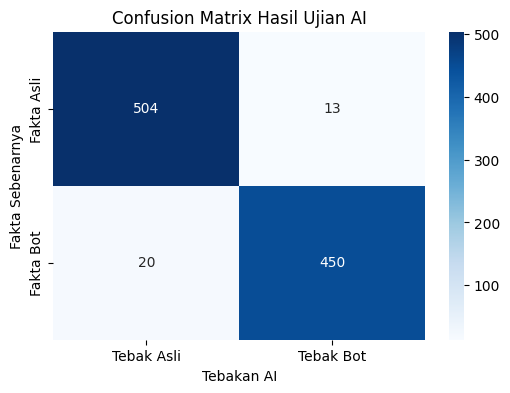

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

print("MEMULAI UJIAN AKHIR (EVALUATION)")

model.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Akurasi Ujian (Test Accuracy) : {test_accuracy * 100:.2f}%")
print(f"Nilai Error Ujian (Test Loss) : {test_loss:.4f}\n")

y_pred_prob = model.predict(X_test_scaled)
y_pred_kelas = (y_pred_prob > 0.5).astype(int)

print("RAPOR DETAIL (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_pred_kelas, target_names=["Asli/Manusia (0)", "Bot (1)"]))

cm = confusion_matrix(y_test, y_pred_kelas)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Tebak Asli", "Tebak Bot"], 
            yticklabels=["Fakta Asli", "Fakta Bot"])
plt.title('Confusion Matrix Hasil Ujian AI')
plt.ylabel('Fakta Sebenarnya')
plt.xlabel('Tebakan AI')
plt.show()

## 8. Inference 
Tahapan ini adalah simulasi dunia nyata. Di tahapan ini akan memuat model dan scaler yang sudah disimpan sebelumnya, lalu memberikan data profil akun baru yang belum pernah dilihat oleh model untuk diprediksi apakah akun tersebut adalah Manusia Asli atau Bot. Karena hanya akan dilakukan prediksi, model dimuat dengan argumen `compile=False` untuk melewati *custom loss function* yang sudah tidak diperlukan lagi.

In [12]:
model_produksi = tf.keras.models.load_model('fake_followers_model.keras', compile=False)
scaler_produksi = joblib.load('scaler.pkl')

data_baru = [
    {"p_pic": 1, "private": 0, "p_name_user": 0, "desc_length": 150, "followers": 850, "follows": 400, "posts": 45, "ext_url": 1, "num_words_name": 2, "ratio_num_username": 0.0, "ratio_num_name": 0.0},
    {"p_pic": 0, "private": 0, "p_name_user": 1, "desc_length": 0, "followers": 2, "follows": 3500, "posts": 0, "ext_url": 0, "num_words_name": 0, "ratio_num_username": 0.8, "ratio_num_name": 0.0}
]

df_baru = pd.DataFrame(data_baru)

data_baru_scaled = scaler_produksi.transform(df_baru).astype('float32')

hasil_prediksi = model_produksi.predict(data_baru_scaled)

print("\\nHASIL AUDIT AKUN:")
for i, probabilitas in enumerate(hasil_prediksi):
    skor = probabilitas[0]
    
    print(f"\\nAkun Sampel #{i+1}:")
    if skor > 0.5:
        print(f"KESIMPULAN: TERDETEKSI SEBAGAI BOT")
        print(f"Tingkat Keyakinan AI: {skor * 100:.2f}%")
    else:
        prob_asli = (1 - skor) * 100
        print(f"KESIMPULAN: MANUSIA ASLI")
        print(f"   Tingkat Keyakinan AI: {prob_asli:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
\nHASIL AUDIT AKUN:
\nAkun Sampel #1:
KESIMPULAN: TERDETEKSI SEBAGAI BOT
Tingkat Keyakinan AI: 100.00%
\nAkun Sampel #2:
KESIMPULAN: MANUSIA ASLI
   Tingkat Keyakinan AI: 100.00%


d:\Capstone Dicoding\Fake-Followers\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [16]:
%reload_ext tensorboard
%tensorboard --logdir logs/fit

Reusing TensorBoard on port 6006 (pid 3060), started 0:02:47 ago. (Use '!kill 3060' to kill it.)